In [1]:
import pandas as pd

dataframe = pd.read_csv("../data/demanda_comercial.csv.zip", compression="zip")
dataframe["Fecha"] = pd.to_datetime(dataframe["Fecha"])
dataframe.head()

,Fecha,H01,H02,H03,H04,H05,H06,H07,H08,H09,...,H15,H16,H17,H18,H19,H20,H21,H22,H23,H24
0,2017-01-01,6090271.96,5887031.28,5708693.89,5538133.02,5389774.53,5288199.94,4851217.85,4876162.18,5073813.27,...,5745568.87,5647807.40,5609297.84,5690105.56,6761038.26,7077861.59,6979468.90,6695312.12,6289107.72,5794545.98
1,2017-01-02,5557603.42,5361012.17,5239119.86,5163721.70,5249539.75,5438852.95,5566947.57,6055220.80,6588005.66,...,7610559.73,7584026.97,7421194.49,7317194.26,8182697.67,8482127.69,8251009.75,7836278.95,7221234.85,6660691.64
2,2017-01-03,6160676.02,5924880.04,5764416.93,5685832.28,5778222.13,5985840.29,6083907.36,6545100.21,7092804.54,...,8148614.93,8117168.00,7930900.03,7783762.28,8653467.38,8835882.88,8562448.23,8095841.79,7443299.51,6840297.15
3,2017-01-04,6321851.20,6092135.24,5905390.85,5827867.82,5925730.02,6182279.89,6276759.96,6737660.53,7256819.19,...,8164513.51,8132006.92,7962749.39,7841533.59,8700506.07,8860255.66,8611085.76,8147451.75,7471240.82,6838250.32
4,2017-01-05,6395397.96,6162409.22,6001153.67,5918673.26,6005924.21,6225027.53,6322923.78,6739120.44,7307847.42,...,8144209.65,8136193.07,8022918.36,7927405.07,8718181.89,8832234.87,8579992.47,8063978.64,7406615.66,6829864.57


In [2]:
dataframe.shape

(2069, 25)

In [3]:
# Cobertura de la serie: rango, huecos y valores nulos

rango = pd.date_range(dataframe.Fecha.min(), dataframe.Fecha.max())

print("desde:", dataframe.Fecha.min().date())
print("hasta:", dataframe.Fecha.max().date())
print("dias faltantes:", len(rango) - len(dataframe))
print("valores nulos:", int(dataframe.isna().sum().sum()))

desde: 2017-01-01
hasta: 2022-08-31
dias faltantes: 0
valores nulos: 0


In [4]:
# Las 24 columnas horarias estan en kWh

horas = [columna for columna in dataframe.columns if columna.startswith("H")]

dataframe[horas].describe().loc[["min", "mean", "max"]].T.head(8)

,min,mean,max
H01,5456007.19,7.127184e+06,8590891.73
H02,5290831.00,6.865608e+06,8270505.59
H03,5176637.57,6.694195e+06,8044779.23
H04,5163721.70,6.617292e+06,7913298.26
H05,5249539.75,6.733691e+06,7992539.11
H06,5288199.94,7.002902e+06,8301788.71
H07,4851217.85,7.116093e+06,8547967.29
H08,4876162.18,7.574582e+06,9092839.73


In [5]:
# Las curvas crudas: el nivel varia entre 4.8 y 11 GWh por hora

import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(1, 25), dataframe[horas].to_numpy().T / 1e6,
        color="#2a78d6", linewidth=0.4, alpha=0.05)
ax.set_xlabel("Hora del dia")
ax.set_ylabel("GWh por hora")
plt.show()

<Figure size 800x400 with 1 Axes>

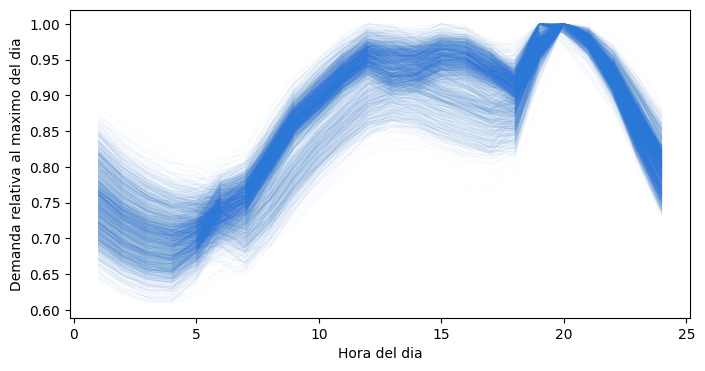

In [6]:
# Normalizacion: cada curva se divide por su propio maximo diario.
#
# Sin este paso el KMeans separa por nivel de consumo (que crece con los
# anos y con la epoca del ano) en vez de separar por la forma de la curva,
# que es el patron que interesa.

normalizadas = dataframe[horas].div(dataframe[horas].max(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(1, 25), normalizadas.to_numpy().T,
        color="#2a78d6", linewidth=0.4, alpha=0.05)
ax.set_xlabel("Hora del dia")
ax.set_ylabel("Demanda relativa al maximo del dia")
plt.show()

In [7]:
# Seleccion del numero de grupos

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

resultados = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=42).fit(normalizadas)

    resultados.append(
        {
            "k": k,
            "inercia": kmeans.inertia_,
            "silhouette": silhouette_score(normalizadas, kmeans.labels_),
        }
    )

pd.DataFrame(resultados)

,k,inercia,silhouette
0,2,25.632155,0.520248
1,3,16.933793,0.382215
2,4,14.351268,0.356467
3,5,12.169896,0.334157
4,6,10.663901,0.330354
5,7,9.612397,0.279514
6,8,8.975938,0.254281
7,9,8.395885,0.251436
8,10,7.853099,0.247281


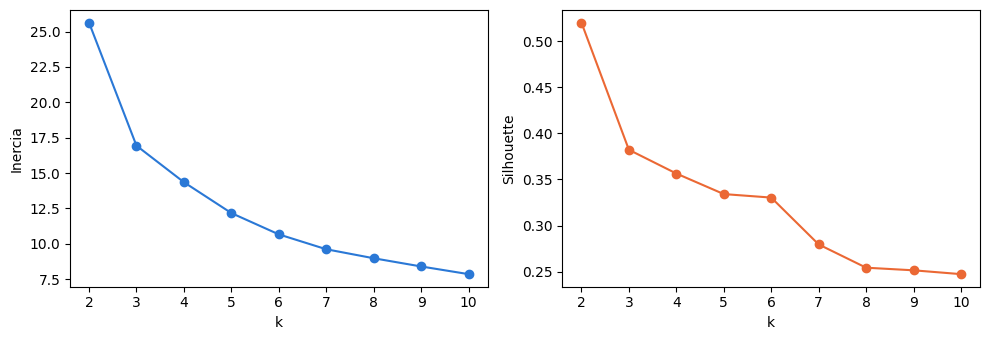

In [8]:
# El silhouette premia k=2 (habiles contra fin de semana), pero la
# inercia deja de caer rapido hacia k=4 y ese nivel de detalle separa
# ademas sabados, domingos y los dos regimenes de dia habil.

resumen = pd.DataFrame(resultados)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(resumen.k, resumen.inercia, marker="o", color="#2a78d6")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inercia")
axes[1].plot(resumen.k, resumen.silhouette, marker="o", color="#eb6834")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")
plt.tight_layout()
plt.show()

In [9]:
# Agrupamiento final

kmeans = KMeans(n_clusters=4, n_init=20, random_state=42).fit(normalizadas)
dataframe["cluster"] = kmeans.labels_

dataframe.cluster.value_counts().sort_index()

cluster
0    419
1    303
2    674
3    673
Name: count, dtype: int64

In [10]:
# Que dia de la semana cae en cada grupo (0 = lunes, 6 = domingo)
#
# El KMeans nunca vio la fecha: solo las 24 columnas horarias.

pd.crosstab(dataframe.cluster, dataframe.Fecha.dt.dayofweek)

Fecha,0,1,2,3,4,5,6
cluster,,,,,,,
0,65,12,9,9,16,19,289
1,1,7,11,10,9,258,7
2,151,150,139,126,90,18,0
3,79,127,137,150,180,0,0


In [11]:
# Los dos grupos de dias habiles no se distinguen por el dia sino por
# el ano: uno domina 2017-2018 y el otro 2021-2022.

pd.crosstab(dataframe.cluster, dataframe.Fecha.dt.year)

Fecha,2017,2018,2019,2020,2021,2022
cluster,,,,,,
0,73,72,69,99,65,41
1,36,48,51,65,62,41
2,249,213,150,42,15,5
3,7,32,95,160,223,156


In [12]:
# Validacion: los dias entre semana que caen en el grupo dominical
# corresponden al calendario de festivos colombianos.

participacion = dataframe.groupby("cluster").Fecha.apply(
    lambda fechas: (fechas.dt.dayofweek == 6).mean()
)

grupo_domingos = participacion.idxmax()

festivos = dataframe[
    (dataframe.cluster == grupo_domingos) & (dataframe.Fecha.dt.dayofweek <= 4)
]

print("dias habiles agrupados con los domingos:", len(festivos))
print(festivos[festivos.Fecha.dt.year == 2017].Fecha.dt.strftime("%Y-%m-%d").tolist())

dias habiles agrupados con los domingos: 111
['2017-01-09', '2017-03-20', '2017-04-13', '2017-04-14', '2017-05-01', '2017-05-29', '2017-06-19', '2017-06-26', '2017-07-03', '2017-07-20', '2017-08-07', '2017-08-21', '2017-10-16', '2017-11-06', '2017-11-13', '2017-12-08', '2017-12-25']


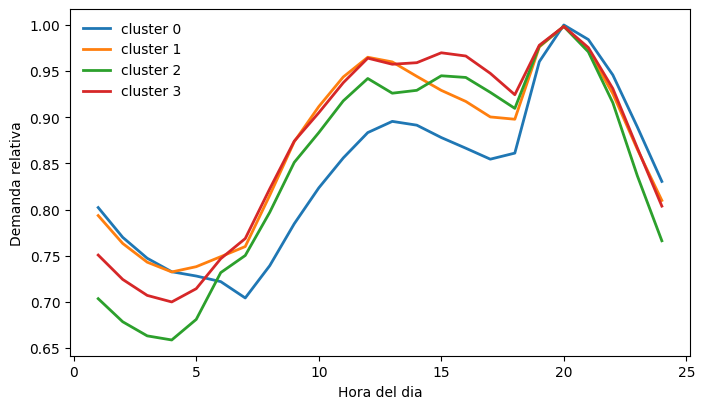

In [13]:
# Perfiles promedio de cada grupo

centros = normalizadas.groupby(dataframe.cluster).mean()

fig, ax = plt.subplots(figsize=(8, 4.5))

for etiqueta, curva in centros.iterrows():
    ax.plot(np.arange(1, 25), curva.to_numpy(), linewidth=2, label=f"cluster {etiqueta}")

ax.set_xlabel("Hora del dia")
ax.set_ylabel("Demanda relativa")
ax.legend(frameon=False)
plt.show()

In [14]:
# Diferencia entre los dos perfiles de dia habil:
# el mas reciente tiene un valle nocturno menos profundo.

centros.T.round(3)

cluster,0,1,2,3
H01,0.802,0.793,0.703,0.751
H02,0.770,0.763,0.678,0.724
H03,0.747,0.743,0.663,0.707
H04,0.733,0.732,0.659,0.700
H05,0.728,0.738,0.681,0.714
H06,0.722,0.749,0.732,0.747
H07,0.704,0.760,0.750,0.769
H08,0.739,0.815,0.797,0.822
H09,0.785,0.874,0.851,0.874
H10,0.823,0.912,0.883,0.905


In [15]:
# Generacion de las tres figuras que verifica el calificador

import sys

sys.path.append("../src")

import clustering

clustering.main()

 cluster   n                        tipo dia_dominante  habiles  ano_mediano
       0 674            97% dias habiles         lunes 0.973294         2018
       1 673           100% dias habiles       viernes 1.000000         2021
       2 303                 85% sabados        sabado 0.125413         2020
       3 419 69% domingos + 111 festivos       domingo 0.264916         2019


Figuras guardadas en C:\Users\danie\dev\Analitica Predictiva\std-daniel-gonzalez-henao\PRE_05_clustering_demanda\submission


,Fecha,H01,H02,H03,H04,H05,H06,H07,H08,H09,...,H16,H17,H18,H19,H20,H21,H22,H23,H24,cluster
0,2017-01-01,6090271.96,5887031.28,5708693.89,5538133.02,5389774.53,5288199.94,4851217.85,4876162.18,5073813.27,...,5647807.40,5609297.84,5690105.56,6761038.26,7077861.59,6979468.90,6695312.12,6289107.72,5794545.98,3
1,2017-01-02,5557603.42,5361012.17,5239119.86,5163721.70,5249539.75,5438852.95,5566947.57,6055220.80,6588005.66,...,7584026.97,7421194.49,7317194.26,8182697.67,8482127.69,8251009.75,7836278.95,7221234.85,6660691.64,0
2,2017-01-03,6160676.02,5924880.04,5764416.93,5685832.28,5778222.13,5985840.29,6083907.36,6545100.21,7092804.54,...,8117168.00,7930900.03,7783762.28,8653467.38,8835882.88,8562448.23,8095841.79,7443299.51,6840297.15,0
3,2017-01-04,6321851.20,6092135.24,5905390.85,5827867.82,5925730.02,6182279.89,6276759.96,6737660.53,7256819.19,...,8132006.92,7962749.39,7841533.59,8700506.07,8860255.66,8611085.76,8147451.75,7471240.82,6838250.32,0
4,2017-01-05,6395397.96,6162409.22,6001153.67,5918673.26,6005924.21,6225027.53,6322923.78,6739120.44,7307847.42,...,8136193.07,8022918.36,7927405.07,8718181.89,8832234.87,8579992.47,8063978.64,7406615.66,6829864.57,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2064,2022-08-27,8019090.28,7715802.90,7512955.20,7384187.49,7428569.45,7538182.92,7745379.95,8384858.53,9094510.08,...,9571674.42,9442496.99,9388268.07,10034777.89,10165411.77,9890022.55,9424859.58,8777510.07,8207763.40,2
2065,2022-08-28,7829228.32,7553474.46,7351742.49,7203292.42,7126988.29,7005971.91,6897850.63,7207841.16,7600341.19,...,8308193.95,8213757.83,8177011.25,8959333.98,9328760.31,9215659.81,8830087.78,8319469.54,7784121.22,3
2066,2022-08-29,7391353.52,7172343.03,7002057.46,6948131.39,7184625.91,7705681.21,7905864.46,8383383.20,8891373.92,...,9872611.80,9764271.47,9510767.15,10021542.34,10253373.69,10036855.68,9514908.18,8777702.80,8168552.76,1
2067,2022-08-30,7773456.57,7540514.20,7376608.54,7302523.58,7473505.20,7949186.98,8170102.83,8599490.98,9057894.84,...,10297871.59,10139832.39,9889406.41,10385155.09,10589342.15,10366488.64,9906914.79,9224079.87,8584316.65,1
